# 06 · Diagnose comma2k19 acceleration bottleneck

목적: 05 baseline에서 `ACCELERATING / DECELERATING` proxy F1이 낮은 원인을 진단한다.

- `stage3/metrics.py`는 수정하지 않는다.
- 기존 `assert_dacon_metric_contract()`로 metric contract만 확인한다.
- proxy threshold는 `vjepa21b_can.yaml`의 diagnostic rule을 그대로 사용한다.
- proxy F1은 DACON 리더보드 점수가 아니다.

진단 항목:
1. dynamic acceleration frame 희소성
2. acceleration prediction의 zero-shrinkage
3. ACCEL/DECEL → CONSTANT confusion
4. temporal lag
5. predicted speed derivative가 direct accel head보다 더 유용한지


In [1]:
from __future__ import annotations

import json, os, shutil, subprocess, sys, time, warnings
from collections import defaultdict
from pathlib import Path

warnings.filterwarnings("ignore", message=r".*torch\.backends\.cuda\.sdp_kernel\(\).*deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=r".*Importing from timm\.models\.layers is deprecated.*", category=FutureWarning)

from google.colab import drive
try:
    drive.mount("/content/drive", force_remount=False)
except Exception:
    drive.mount("/content/drive", force_remount=True)

REPO = Path("/content/Blackbox-Detection")
REPO_URL = "https://github.com/sangchun1/Blackbox-Detection.git"
BRANCH = "stage3-sangchun"

if not (REPO / ".git").is_dir():
    subprocess.run(["git","clone","--depth","1","--branch",BRANCH,"--single-branch",REPO_URL,str(REPO)], check=True)
else:
    branch = subprocess.run(["git","-C",str(REPO),"branch","--show-current"],capture_output=True,text=True,check=True).stdout.strip()
    if branch != BRANCH:
        subprocess.run(["git","-C",str(REPO),"checkout",BRANCH], check=True)
    dirty = subprocess.run(["git","-C",str(REPO),"status","--porcelain"],capture_output=True,text=True,check=True).stdout.strip()
    if not dirty:
        subprocess.run(["git","-C",str(REPO),"pull","--ff-only","origin",BRANCH], check=True)
    else:
        print("WARNING: local repo has changes; pull skipped.")

subprocess.run([sys.executable,"-m","pip","install","-q","--no-deps","-e",str(REPO)], check=True)
if str(REPO/"src") not in sys.path:
    sys.path.insert(0, str(REPO/"src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, yaml
from sklearn.metrics import confusion_matrix, f1_score
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from blackbox_detection.stage3.constants import CAN_TARGETS
from blackbox_detection.stage3.metrics import ACCEL_CLASSES, dacon_stage3_metrics, denormalize
from blackbox_detection.stage3.proxy_metrics import ProxyRule, _proxy_labels, assert_dacon_metric_contract
from blackbox_detection.stage3.schema import read_frame_table
from blackbox_detection.utils import dataloader_seed_kwargs, seed_everything

DRIVE_ROOT = Path("/content/drive/MyDrive/Blackbox-Detection")
PROCESSED_ROOT = DRIVE_ROOT/"DATASET"/"comma2k19"/"processed"/"v1"
MANIFEST_ROOT = DRIVE_ROOT/"manifests"/"stage3"/"v1"
OUTPUT_ROOT = DRIVE_ROOT/"outputs"/"stage3"
PRETRAINED_ROOT = DRIVE_ROOT/"pretrained"

CFG_PATH = REPO/"configs"/"stage3"/"vjepa21b_can.yaml"
cfg = yaml.safe_load(CFG_PATH.read_text())
stats = json.loads((MANIFEST_ROOT/"target_stats.json").read_text())

SEED = int(cfg["seed"])
seed_everything(SEED, deterministic=False)

RUN_VARIANT = cfg.get("experiment",{}).get("name","vjepa21b_can_v1")
RUN_DIR = OUTPUT_ROOT/RUN_VARIANT
DIAG_DIR = RUN_DIR/"diagnostics_accel_v1"
LOCAL_DIAG_DIR = Path("/content/stage3_diag")/RUN_VARIANT/"diagnostics_accel_v1"
LOCAL_DIAG_DIR.mkdir(parents=True, exist_ok=True)
DIAG_DIR.mkdir(parents=True, exist_ok=True)

assert_dacon_metric_contract()
print("DACON metric contract: PASS (metrics.py unchanged)")
print("run:", RUN_VARIANT)
print("diagnostics:", DIAG_DIR)


Mounted at /content/drive
DACON metric contract: PASS (metrics.py unchanged)
run: vjepa21b_can_v1
diagnostics: /content/drive/MyDrive/Blackbox-Detection/outputs/stage3/vjepa21b_can_v1/diagnostics_accel_v1


In [2]:
def usable(path: Path, min_bytes=1):
    try:
        return path.is_file() and path.stat().st_size >= min_bytes
    except OSError:
        return False

def copy_local(src: Path, dst: Path, min_bytes=1, retries=2):
    dst.parent.mkdir(parents=True, exist_ok=True)
    err = None
    for attempt in range(retries+1):
        tmp = dst.with_name(dst.name+".tmp")
        try:
            tmp.unlink(missing_ok=True)
            with src.open("rb") as fsrc, tmp.open("wb") as fdst:
                shutil.copyfileobj(fsrc, fdst, length=16*1024*1024)
            if tmp.stat().st_size < min_bytes:
                raise OSError("file too small")
            os.replace(tmp,dst)
            return True
        except OSError as e:
            err=e
            tmp.unlink(missing_ok=True)
            time.sleep(attempt+1)
    print("copy failed:", repr(err))
    return False

VJEPA_REPO = Path("/content/vjepa2")
VJEPA_COMMIT = "45d025f636dfc58fc2426905fc4a1ab755b1c3e5"
if not (VJEPA_REPO/".git").is_dir():
    subprocess.run(["git","clone","-q","https://github.com/facebookresearch/vjepa2.git",str(VJEPA_REPO)],check=True)
subprocess.run(["git","-C",str(VJEPA_REPO),"checkout","-q",VJEPA_COMMIT],check=True)

LOCAL_PRETRAINED = Path("/content/pretrained")
LOCAL_PRETRAINED.mkdir(exist_ok=True)
VJEPA_NAME = "vjepa2_1_vitb_dist_vitG_384.pt"
VJEPA_DRIVE = PRETRAINED_ROOT/VJEPA_NAME
VJEPA_CKPT = LOCAL_PRETRAINED/VJEPA_NAME

if not usable(VJEPA_CKPT, 1_000_000_000):
    if not copy_local(VJEPA_DRIVE, VJEPA_CKPT, 1_000_000_000, 2):
        url="https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt"
        subprocess.run(["wget","-q","--show-progress","-O",str(VJEPA_CKPT),url],check=True)

MODEL_CKPT_DRIVE = RUN_DIR/"best.pt"
if not usable(MODEL_CKPT_DRIVE):
    MODEL_CKPT_DRIVE = RUN_DIR/"latest.pt"
if not usable(MODEL_CKPT_DRIVE):
    raise FileNotFoundError("best.pt/latest.pt not found")

LOCAL_MODEL_CKPT = Path("/content/stage3_diag")/RUN_VARIANT/MODEL_CKPT_DRIVE.name
if not usable(LOCAL_MODEL_CKPT):
    if not copy_local(MODEL_CKPT_DRIVE, LOCAL_MODEL_CKPT, 1, 3):
        raise OSError("Could not stage model checkpoint to /content")

print("vjepa:", VJEPA_CKPT)
print("model:", LOCAL_MODEL_CKPT)


vjepa: /content/pretrained/vjepa2_1_vitb_dist_vitG_384.pt
model: /content/stage3_diag/vjepa21b_can_v1/best.pt


In [3]:
from blackbox_detection.stage3.dataset import Stage3CANDataset
from blackbox_detection.stage3.models import VJEPA21DenseCAN
from blackbox_detection.stage3.vjepa21 import load_vjepa21_base_encoder
from blackbox_detection.utils.checkpoint import load_checkpoint

dc, tc = cfg["data"], cfg["training"]
proxy_rules = {k: ProxyRule.from_mapping(v) for k,v in cfg.get("validation",{}).get("proxy_rules",{}).items()}
if not proxy_rules:
    raise ValueError("validation.proxy_rules missing")

train_ds = Stage3CANDataset(
    MANIFEST_ROOT/"comma_train.csv", PROCESSED_ROOT, target_stats=stats,
    clip_len=dc["clip_len"], window_stride=dc["window_stride"],
    input_size=(dc["input_height"],dc["input_width"]), random_flip=False,
    max_windows=dc["max_train_windows"], seed=SEED,
)
val_ds = Stage3CANDataset(
    MANIFEST_ROOT/"comma_val_id.csv", PROCESSED_ROOT, target_stats=stats,
    clip_len=dc["clip_len"], window_stride=dc["window_stride"],
    input_size=(dc["input_height"],dc["input_width"]), random_flip=False,
    max_windows=dc["max_val_windows"], seed=SEED+1,
)
val_loader = DataLoader(
    val_ds, batch_size=tc["batch_size"], shuffle=False,
    num_workers=dc["num_workers"], pin_memory=True,
    persistent_workers=dc["num_workers"]>0,
    **dataloader_seed_kwargs(SEED+1),
)

mc = cfg["model"]
backbone = load_vjepa21_base_encoder(
    VJEPA_REPO, VJEPA_CKPT, num_frames=dc["clip_len"],
    out_layers=tuple(mc["out_layers"]), freeze=mc["freeze_backbone"],
)
model = VJEPA21DenseCAN(
    backbone, freeze_backbone=mc["freeze_backbone"],
    feature_dim=mc["feature_dim"], temporal_hidden=mc["temporal_hidden"],
    temporal_layers=mc["temporal_layers"],
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
meta = load_checkpoint(LOCAL_MODEL_CKPT, model=model, map_location="cpu", restore_rng_state=False)
model.eval()

MAX_VAL_STEPS = int(tc.get("max_val_steps",500))
print("checkpoint epoch:", meta.get("epoch"))
print("train windows:", len(train_ds), "| val windows:", len(val_ds), "| diag val steps:", MAX_VAL_STEPS)


checkpoint epoch: 4
train windows: 12000 | val windows: 4000 | diag val steps: 500


In [4]:
@torch.inference_mode()
def collect_predictions():
    rows=[]
    for step,batch in enumerate(tqdm(val_loader,total=MAX_VAL_STEPS,desc="Val inference")):
        if step>=MAX_VAL_STEPS: break
        video=batch["video"].to(device,non_blocking=True)
        target=batch["target"].float().cpu().numpy()
        valid=batch["valid"].cpu().numpy().astype(bool)
        with torch.autocast(device_type=device.type,dtype=torch.bfloat16,enabled=device.type=="cuda"):
            out=model(video)
        pred_norm={n:out[n].detach().float().cpu().numpy() for n in CAN_TARGETS}
        gt={n:denormalize(target[...,i],stats[n]) for i,n in enumerate(CAN_TARGETS)}
        pr={n:denormalize(pred_norm[n],stats[n]) for n in CAN_TARGETS}
        B,T=target.shape[:2]
        for b in range(B):
            wid=step*int(tc["batch_size"])+b
            for t in range(T):
                row={"window_id":wid,"t":t,"route_id":str(batch["route_id"][b]),
                     "segment_id":str(batch["segment_id"][b]),"start":int(batch["start"][b])}
                for i,n in enumerate(CAN_TARGETS):
                    row[f"gt_{n}"]=float(gt[n][b,t])
                    row[f"pred_{n}"]=float(pr[n][b,t])
                    row[f"valid_{n}"]=bool(valid[b,t,i])
                rows.append(row)
    return pd.DataFrame(rows)

pred_df=collect_predictions()
pred_df.to_csv(LOCAL_DIAG_DIR/"val_frame_predictions.csv",index=False)
print(pred_df.shape, "windows:", pred_df.window_id.nunique())
display(pred_df.head())


Val inference:   0%|          | 0/500 [00:00<?, ?it/s]

(16000, 17) windows: 1000


,window_id,t,route_id,segment_id,start,gt_speed_mps,pred_speed_mps,valid_speed_mps,gt_accel_from_speed_mps2,pred_accel_from_speed_mps2,valid_accel_from_speed_mps2,gt_steering_deg,pred_steering_deg,valid_steering_deg,gt_yaw_rate_rps,pred_yaw_rate_rps,valid_yaw_rate_rps
0,0,0,99c94dc769b5d96e|2018-11-13--10-09-22,43,32,30.198549,32.141788,True,-0.015961,-0.013040,True,4.4,1.496841,True,-0.057002,-0.009251,True
1,0,1,99c94dc769b5d96e|2018-11-13--10-09-22,43,32,30.195618,32.448353,True,-0.039275,-0.023300,True,4.4,2.128155,True,-0.060919,-0.013136,True
2,0,2,99c94dc769b5d96e|2018-11-13--10-09-22,43,32,30.190695,32.229378,True,-0.044210,-0.024150,True,4.4,2.462943,True,-0.063292,-0.016687,True
3,0,3,99c94dc769b5d96e|2018-11-13--10-09-22,43,32,30.186775,31.966612,True,-0.056406,-0.020022,True,4.4,2.405550,True,-0.065655,-0.018208,True
4,0,4,99c94dc769b5d96e|2018-11-13--10-09-22,43,32,30.179415,31.966612,True,-0.081471,-0.018564,True,4.4,2.386420,True,-0.059404,-0.018643,True


In [5]:
def collect_train_gt(dataset):
    grouped=defaultdict(list)
    for wid,(seg_idx,start) in enumerate(dataset.windows):
        grouped[int(seg_idx)].append((wid,int(start)))
    chunks=[]
    for seg_idx,specs in tqdm(grouped.items(),desc="Train metadata"):
        row=dataset.segments.iloc[seg_idx]
        meta=read_frame_table(dataset.processed_root/str(row.metadata_relpath))
        for wid,start in specs:
            c=meta.iloc[start:start+dataset.clip_len]
            if len(c)!=dataset.clip_len: continue
            chunks.append(pd.DataFrame({
                "window_id":wid,
                "gt_speed_mps":c["speed_mps"].to_numpy(np.float32),
                "gt_accel_from_speed_mps2":c["accel_from_speed_mps2"].to_numpy(np.float32),
                "gt_steering_deg":c["steering_deg"].to_numpy(np.float32),
                "valid_speed_mps":c["valid_speed"].to_numpy(bool),
                "valid_accel_from_speed_mps2":c["valid_accel_from_speed"].to_numpy(bool),
                "valid_steering_deg":c["valid_steer"].to_numpy(bool),
            }))
    return pd.concat(chunks,ignore_index=True)

train_gt=collect_train_gt(train_ds)

def balance(frame,name):
    mask=(frame.valid_speed_mps.to_numpy(bool)&frame.valid_accel_from_speed_mps2.to_numpy(bool)&frame.valid_steering_deg.to_numpy(bool))
    speed=frame.loc[mask,"gt_speed_mps"].to_numpy(float)
    accel=frame.loc[mask,"gt_accel_from_speed_mps2"].to_numpy(float)
    steer=frame.loc[mask,"gt_steering_deg"].to_numpy(float)
    rows=[]
    for rname,rule in proxy_rules.items():
        la,_=_proxy_labels(speed,accel,steer,rule)
        vc=pd.Series(la).value_counts()
        for cls in ACCEL_CLASSES:
            cnt=int(vc.get(cls,0))
            rows.append({"dataset":name,"rule":rname,"class":cls,"count":cnt,"fraction":cnt/max(len(la),1)})
    return pd.DataFrame(rows)

val_gt=pred_df[["gt_speed_mps","gt_accel_from_speed_mps2","gt_steering_deg",
                    "valid_speed_mps","valid_accel_from_speed_mps2","valid_steering_deg"]].copy()
balance_df=pd.concat([balance(train_gt,"train"),balance(val_gt,"val")],ignore_index=True)
balance_df.to_csv(LOCAL_DIAG_DIR/"proxy_accel_class_balance.csv",index=False)
display(balance_df.pivot_table(index=["dataset","rule"],columns="class",values="fraction").round(4))


Train metadata:   0%|          | 0/1649 [00:00<?, ?it/s]

class                 ACCELERATING  CONSTANT  DECELERATING  STOPPED
dataset rule                                                       
train   conservative        0.1307    0.6361        0.1269   0.1063
        medium              0.1789    0.5480        0.1717   0.1014
        sensitive           0.2670    0.3794        0.2533   0.1003
val     conservative        0.1505    0.6044        0.1293   0.1157
        medium              0.2097    0.5066        0.1756   0.1082
        sensitive           0.2911    0.3454        0.2570   0.1065

,value
n,15959.000000
gt_std,0.485229
pred_std,0.034473
std_ratio_pred_over_gt,0.071044
pearson_corr,0.239818
linear_slope_pred_vs_gt,0.017038
mae,0.278500
bias,-0.001703


,abs_gt_lo,abs_gt_hi,n,gt_abs_mean,pred_abs_mean,mae,sign_accuracy
0,0.00,0.10,7119,0.034405,0.022443,0.044677,0.385728
1,0.10,0.20,2579,0.144788,0.021336,0.143348,0.530438
2,0.20,0.30,1611,0.246855,0.024685,0.242116,0.558038
3,0.30,0.50,1842,0.389305,0.028387,0.381190,0.590662
4,0.50,0.75,1233,0.606884,0.034852,0.594724,0.639903
5,0.75,1.00,634,0.861410,0.034216,0.849145,0.610410
6,1.00,1.50,573,1.220597,0.035409,1.206114,0.621291
7,1.50,inf,368,1.943992,0.047235,1.907267,0.809783


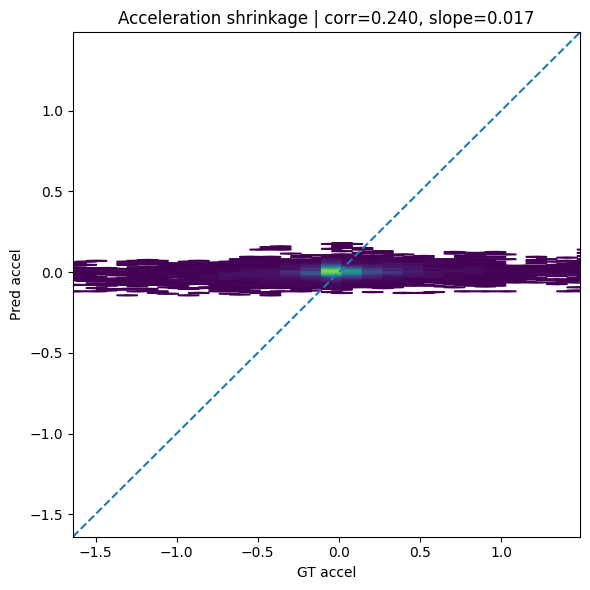

In [6]:
mask=pred_df.valid_accel_from_speed_mps2.to_numpy(bool)
a=pred_df.loc[mask,"gt_accel_from_speed_mps2"].to_numpy(float)
p=pred_df.loc[mask,"pred_accel_from_speed_mps2"].to_numpy(float)
finite=np.isfinite(a)&np.isfinite(p)
a,p=a[finite],p[finite]

corr=float(np.corrcoef(a,p)[0,1])
slope,intercept=np.polyfit(a,p,1)
shrink={
    "n":len(a),"gt_std":float(a.std()),"pred_std":float(p.std()),
    "std_ratio_pred_over_gt":float(p.std()/max(a.std(),1e-12)),
    "pearson_corr":corr,"linear_slope_pred_vs_gt":float(slope),
    "mae":float(np.mean(np.abs(p-a))),"bias":float(np.mean(p-a)),
}
display(pd.DataFrame([shrink]).T.rename(columns={0:"value"}))

edges=np.array([0,.1,.2,.3,.5,.75,1,1.5,np.inf])
rows=[]
for lo,hi in zip(edges[:-1],edges[1:]):
    m=(np.abs(a)>=lo)&(np.abs(a)<hi)
    if not m.any(): continue
    rows.append({"abs_gt_lo":lo,"abs_gt_hi":hi,"n":int(m.sum()),
                 "gt_abs_mean":float(np.abs(a[m]).mean()),"pred_abs_mean":float(np.abs(p[m]).mean()),
                 "mae":float(np.abs(p[m]-a[m]).mean()),
                 "sign_accuracy":float(np.mean(np.sign(p[m])==np.sign(a[m])))})
mag_df=pd.DataFrame(rows)
mag_df.to_csv(LOCAL_DIAG_DIR/"accel_magnitude_bins.csv",index=False)
display(mag_df)

plt.figure(figsize=(6,6))
idx=np.random.default_rng(SEED).choice(len(a),size=min(12000,len(a)),replace=False)
plt.hexbin(a[idx],p[idx],gridsize=60,mincnt=1)
lo=min(np.quantile(a[idx],.01),np.quantile(p[idx],.01))
hi=max(np.quantile(a[idx],.99),np.quantile(p[idx],.99))
plt.plot([lo,hi],[lo,hi],"--")
plt.xlim(lo,hi); plt.ylim(lo,hi)
plt.xlabel("GT accel"); plt.ylabel("Pred accel")
plt.title(f"Acceleration shrinkage | corr={corr:.3f}, slope={slope:.3f}")
plt.tight_layout(); plt.savefig(LOCAL_DIAG_DIR/"accel_scatter.png",dpi=160); plt.show()


In [7]:
common=(pred_df.valid_speed_mps.to_numpy(bool)&pred_df.valid_accel_from_speed_mps2.to_numpy(bool)&pred_df.valid_steering_deg.to_numpy(bool))
gt_s=pred_df.loc[common,"gt_speed_mps"].to_numpy(float)
gt_a=pred_df.loc[common,"gt_accel_from_speed_mps2"].to_numpy(float)
gt_st=pred_df.loc[common,"gt_steering_deg"].to_numpy(float)
pr_s=pred_df.loc[common,"pred_speed_mps"].to_numpy(float)
pr_a=pred_df.loc[common,"pred_accel_from_speed_mps2"].to_numpy(float)
pr_st=pred_df.loc[common,"pred_steering_deg"].to_numpy(float)

cms={}
scores=[]
for rname,rule in proxy_rules.items():
    ta,ts=_proxy_labels(gt_s,gt_a,gt_st,rule)
    pa,ps=_proxy_labels(pr_s,pr_a,pr_st,rule)
    score=dacon_stage3_metrics(ta,pa,ts,ps)
    f1s=f1_score(ta,pa,labels=list(ACCEL_CLASSES),average=None,zero_division=0)
    cm=confusion_matrix(ta,pa,labels=list(ACCEL_CLASSES))
    cmn=cm/np.maximum(cm.sum(axis=1,keepdims=True),1)
    df=pd.DataFrame(cmn,index=[f"GT_{x}" for x in ACCEL_CLASSES],columns=[f"PRED_{x}" for x in ACCEL_CLASSES])
    df.to_csv(LOCAL_DIAG_DIR/f"accel_confusion_{rname}.csv")
    cms[rname]=df
    row={"rule":rname,**score}
    row.update({f"f1_{c}":float(v) for c,v in zip(ACCEL_CLASSES,f1s)})
    scores.append(row)

display(pd.DataFrame(scores))
for k,v in cms.items():
    print("\n",k); display(v.round(3))


,rule,stage3_score,accel_macro_f1,steer_macro_f1,steer_eval_frames,f1_ACCELERATING,f1_DECELERATING,f1_CONSTANT,f1_STOPPED
0,sensitive,0.437696,0.373272,0.588021,14259,0.021133,0.048654,0.551839,0.871461
1,medium,0.452971,0.402947,0.569692,14233,0.000000,0.000000,0.716013,0.895775
2,conservative,0.487210,0.434325,0.610609,14112,0.000000,0.000000,0.805436,0.931863



 sensitive


,PRED_ACCELERATING,PRED_DECELERATING,PRED_CONSTANT,PRED_STOPPED
GT_ACCELERATING,0.011,0.004,0.983,0.003
GT_DECELERATING,0.004,0.025,0.966,0.005
GT_CONSTANT,0.003,0.002,0.995,0.000
GT_STOPPED,0.003,0.001,0.209,0.788



 medium


,PRED_ACCELERATING,PRED_DECELERATING,PRED_CONSTANT,PRED_STOPPED
GT_ACCELERATING,0.0,0.0,0.997,0.003
GT_DECELERATING,0.0,0.0,0.991,0.009
GT_CONSTANT,0.0,0.0,1.000,0.000
GT_STOPPED,0.0,0.0,0.171,0.829



 conservative


,PRED_ACCELERATING,PRED_DECELERATING,PRED_CONSTANT,PRED_STOPPED
GT_ACCELERATING,0.0,0.0,0.998,0.002
GT_DECELERATING,0.0,0.0,0.989,0.011
GT_CONSTANT,0.0,0.0,0.998,0.002
GT_STOPPED,0.0,0.0,0.108,0.892


In [8]:
def lag_scan(frame,max_lag=5):
    rows=[]
    for lag in range(-max_lag,max_lag+1):
        xs=[]; ys=[]
        for _,w in frame.groupby("window_id",sort=False):
            w=w.sort_values("t")
            x=w.gt_accel_from_speed_mps2.to_numpy(float)
            y=w.pred_accel_from_speed_mps2.to_numpy(float)
            v=w.valid_accel_from_speed_mps2.to_numpy(bool)
            if lag>0: xx,yy,m=x[:-lag],y[lag:],v[:-lag]&v[lag:]
            elif lag<0:
                k=-lag; xx,yy,m=x[k:],y[:-k],v[k:]&v[:-k]
            else: xx,yy,m=x,y,v
            m&=np.isfinite(xx)&np.isfinite(yy)
            if m.any(): xs.append(xx[m]); ys.append(yy[m])
        xx=np.concatenate(xs); yy=np.concatenate(ys)
        rows.append({"lag_frames":lag,"lag_seconds":lag/10,"correlation":float(np.corrcoef(xx,yy)[0,1]),
                     "mae":float(np.mean(np.abs(xx-yy))),"n":len(xx)})
    return pd.DataFrame(rows)

lag_df=lag_scan(pred_df)
lag_df.to_csv(LOCAL_DIAG_DIR/"accel_lag_scan.csv",index=False)
display(lag_df)
best_lag=lag_df.loc[lag_df.correlation.idxmax()]

cons=[]
for wid,w in pred_df.groupby("window_id",sort=False):
    w=w.sort_values("t")
    if len(w)<3: continue
    ga=w.gt_accel_from_speed_mps2.to_numpy(float)
    pa=w.pred_accel_from_speed_mps2.to_numpy(float)
    gv=w.gt_speed_mps.to_numpy(float)
    pv=w.pred_speed_mps.to_numpy(float)
    valid=w.valid_accel_from_speed_mps2.to_numpy(bool)&w.valid_speed_mps.to_numpy(bool)
    dgp=np.gradient(gv,.1); dpp=np.gradient(pv,.1)
    for i in range(len(w)):
        if valid[i] and np.isfinite([ga[i],pa[i],dgp[i],dpp[i]]).all():
            cons.append((ga[i],pa[i],dgp[i],dpp[i]))
cons=np.asarray(cons,float)

def corr(x,y): return float(np.corrcoef(x,y)[0,1])
consistency={
    "corr_gt_accel__pred_accel":corr(cons[:,0],cons[:,1]),
    "corr_gt_accel__d_pred_speed":corr(cons[:,0],cons[:,3]),
    "corr_pred_accel__d_pred_speed":corr(cons[:,1],cons[:,3]),
    "corr_gt_accel__d_gt_speed":corr(cons[:,0],cons[:,2]),
}
pd.DataFrame([consistency]).to_csv(LOCAL_DIAG_DIR/"speed_accel_consistency.csv",index=False)
display(pd.DataFrame([consistency]).T.rename(columns={0:"value"}))


,lag_frames,lag_seconds,correlation,mae,n
0,-5,-0.5,0.227893,0.281018,10959
1,-4,-0.4,0.234268,0.280363,11959
2,-3,-0.3,0.238803,0.279746,12959
3,-2,-0.2,0.241019,0.279204,13959
4,-1,-0.1,0.241367,0.278750,14959
5,0,0.0,0.239818,0.278500,15959
6,1,0.1,0.239421,0.277892,14959
7,2,0.2,0.236683,0.277325,13959
8,3,0.3,0.232769,0.276796,12959
9,4,0.4,0.228035,0.276258,11959


,value
corr_gt_accel__pred_accel,0.239818
corr_gt_accel__d_pred_speed,0.078690
corr_pred_accel__d_pred_speed,0.185549
corr_gt_accel__d_gt_speed,0.999620


In [9]:
primary="medium" if "medium" in proxy_rules else next(iter(proxy_rules))
b=balance_df[(balance_df.dataset=="train")&(balance_df.rule==primary)]
dyn=float(b[b["class"].isin(["ACCELERATING","DECELERATING"])].fraction.sum())

cm=cms[primary]
dyn_to_const=float(np.mean([
    cm.loc["GT_ACCELERATING","PRED_CONSTANT"],
    cm.loc["GT_DECELERATING","PRED_CONSTANT"],
]))

summary={
    "checkpoint_epoch":int(meta.get("epoch") or -1),
    "diagnostic_proxy_rule":primary,
    "train_dynamic_fraction":dyn,
    "accel_gt_std":shrink["gt_std"],
    "accel_pred_std":shrink["pred_std"],
    "accel_pred_to_gt_std_ratio":shrink["std_ratio_pred_over_gt"],
    "accel_prediction_slope":shrink["linear_slope_pred_vs_gt"],
    "accel_prediction_corr":shrink["pearson_corr"],
    "dynamic_to_constant_confusion_mean":dyn_to_const,
    "best_lag_frames":int(best_lag.lag_frames),
    "best_lag_seconds":float(best_lag.lag_seconds),
    **consistency,
    "important_note":"Proxy thresholds are diagnostic only; metrics.py was not changed."
}

rec=[]
if dyn<.25: rec.append("HIGH: dynamic-aware window sampling / oversampling")
if shrink["std_ratio_pred_over_gt"]<.7 or shrink["linear_slope_pred_vs_gt"]<.7:
    rec.append("HIGH: acceleration magnitude shrinkage -> sign/magnitude auxiliary supervision")
if dyn_to_const>.4: rec.append("HIGH: ACCEL/DECEL collapse to CONSTANT")
if abs(int(best_lag.lag_frames))>=1: rec.append("MEDIUM/HIGH: temporal alignment/context ablation")
if consistency["corr_gt_accel__d_pred_speed"]>consistency["corr_gt_accel__pred_accel"]+.05:
    rec.append("HIGH: add speed-derivative consistency")
summary["recommendations"]=rec

summary_path=LOCAL_DIAG_DIR/"diagnostic_summary.json"
summary_path.write_text(json.dumps(summary,indent=2),encoding="utf-8")
print(json.dumps(summary,indent=2))

for f in LOCAL_DIAG_DIR.iterdir():
    if f.is_file():
        shutil.copy2(f, DIAG_DIR/f.name)

print("\nSaved:",DIAG_DIR)
print("Send diagnostic_summary.json (and, if convenient, the 3 CSVs).")


{
  "checkpoint_epoch": 4,
  "diagnostic_proxy_rule": "medium",
  "train_dynamic_fraction": 0.35067330654390205,
  "accel_gt_std": 0.48522941502640576,
  "accel_pred_std": 0.034472775077703605,
  "accel_pred_to_gt_std_ratio": 0.07104428134437733,
  "accel_prediction_slope": 0.017037714252099746,
  "accel_prediction_corr": 0.23981823631252988,
  "dynamic_to_constant_confusion_mean": 0.9940735910179435,
  "best_lag_frames": -1,
  "best_lag_seconds": -0.1,
  "corr_gt_accel__pred_accel": 0.23981823631252988,
  "corr_gt_accel__d_pred_speed": 0.07869006218902357,
  "corr_pred_accel__d_pred_speed": 0.1855490642194405,
  "corr_gt_accel__d_gt_speed": 0.9996198339701625,
  "important_note": "Proxy thresholds are diagnostic only; metrics.py was not changed.",
  "recommendations": [
    "HIGH: acceleration magnitude shrinkage -> sign/magnitude auxiliary supervision",
    "HIGH: ACCEL/DECEL collapse to CONSTANT",
    "MEDIUM/HIGH: temporal alignment/context ablation"
  ]
}

Saved: /content/drive/My

## 보내줄 것

데이터셋이나 체크포인트는 다시 보낼 필요 없다.

노트북 실행 후 아래만 보내면 된다.

1. `diagnostic_summary.json` — 필수
2. `proxy_accel_class_balance.csv` — 가능하면
3. `accel_magnitude_bins.csv` — 가능하면
4. `accel_lag_scan.csv` — 가능하면

저 네 개로 v2의 dynamic-aware sampling / auxiliary loss / speed-derivative consistency / temporal context 중 우선순위를 정한다.
